Modification using Kernels

- reducing noise
- erosion or dilation


In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [45]:
def load_img():
  blank_img = np.zeros((600,600))
  font = cv2.FONT_HERSHEY_SIMPLEX
  cv2.putText(blank_img, text='ABCDE', org=(50,300), fontFace=font, fontScale=5, color=(255,255,255),thickness=25)
  return blank_img


In [46]:
def display_img(img):
  fig = plt.figure(figsize=(10,8))
  ax = fig.add_subplot(111)
  ax.imshow(img, cmap='gray')

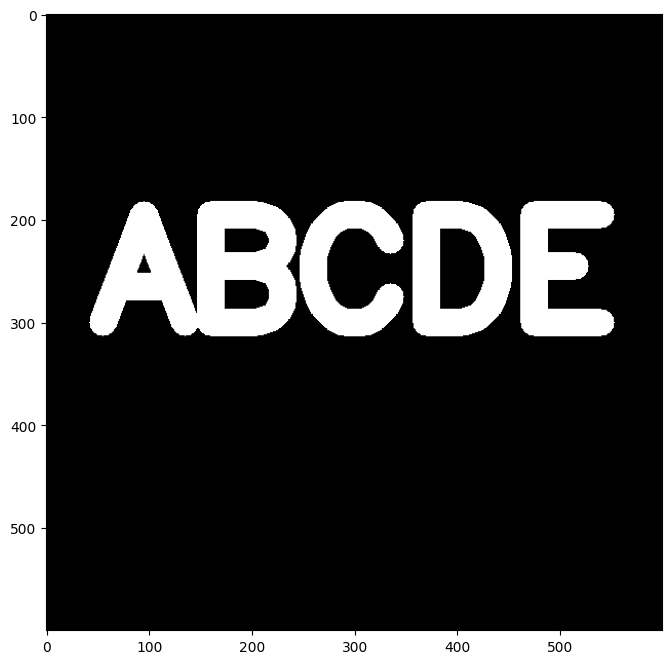

In [47]:
img = load_img()
display_img(img)

In [48]:
kernel = np.ones((5,5), dtype=np.uint8)

In [49]:
kernel

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

In [50]:
result = cv2.erode(img, kernel, iterations=4)

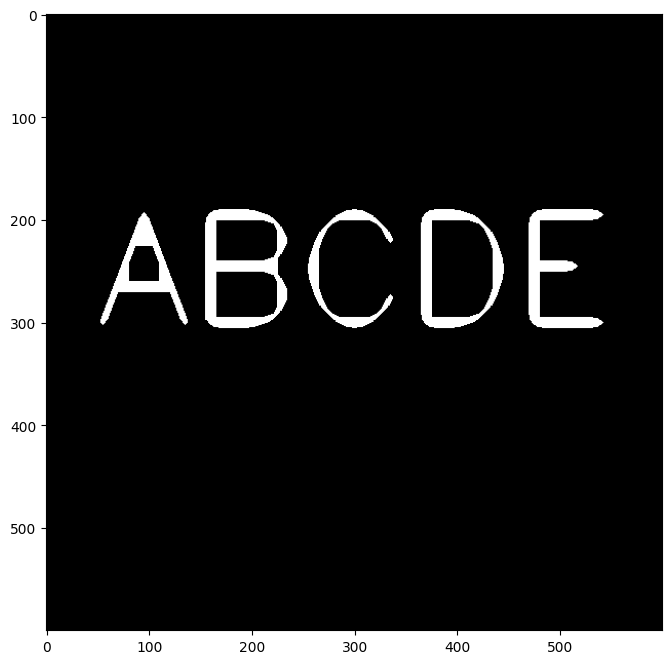

In [51]:
display_img(result)

Opening - Erosion followed by Dilation

Helps remove background noise

In [52]:
img = load_img()

In [55]:
white_noise = np.random.randint(low=0,high=2,size=(600,600))

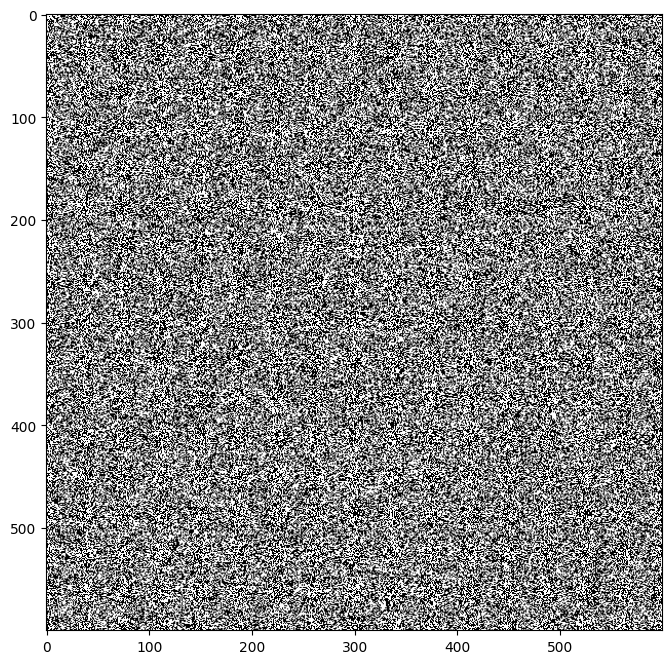

In [56]:
display_img(white_noise)

In [57]:
img.max()

255.0

In [58]:
white_noise = white_noise * 255

In [59]:
white_noise

array([[255,   0,   0, ...,   0, 255,   0],
       [255, 255, 255, ...,   0,   0,   0],
       [  0, 255, 255, ..., 255, 255, 255],
       ...,
       [255,   0,   0, ...,   0,   0, 255],
       [  0,   0,   0, ..., 255, 255,   0],
       [  0,   0, 255, ...,   0,   0, 255]])

In [61]:
noise_img = white_noise + img

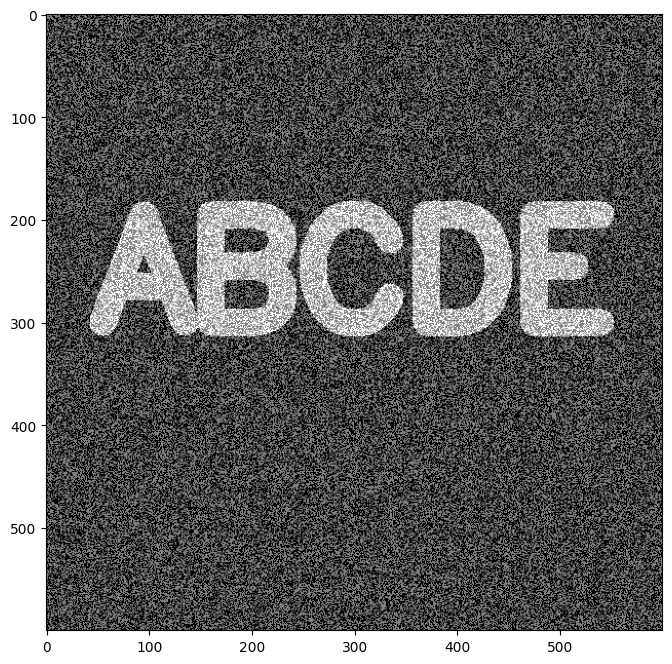

In [62]:
display_img(noise_img)

# morphologyEX

In [63]:
opening = cv2.morphologyEx(noise_img, cv2.MORPH_OPEN, kernel)

Text(0.5, 1.0, 'Opening')

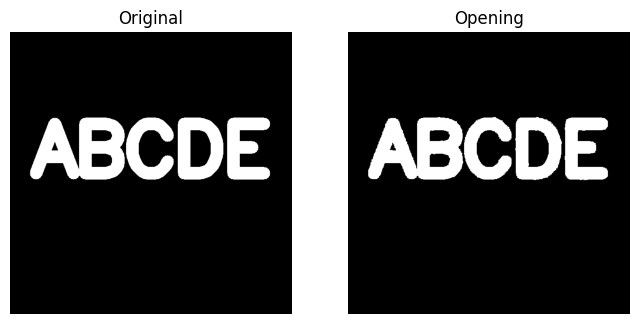

In [67]:
plt.figure(figsize=(8,6))
plt.subplot(121)
plt.axis('off')
plt.imshow(img, cmap='gray')
plt.title('Original')

plt.subplot(122)
plt.axis('off')
plt.imshow(opening,cmap='gray')
plt.title('Opening')

#display_img(opening)

In [68]:
img = load_img()

In [70]:
black_noise = np.random.randint(low=0, high=2, size=(600,600))

In [71]:
black_noise = black_noise * -255

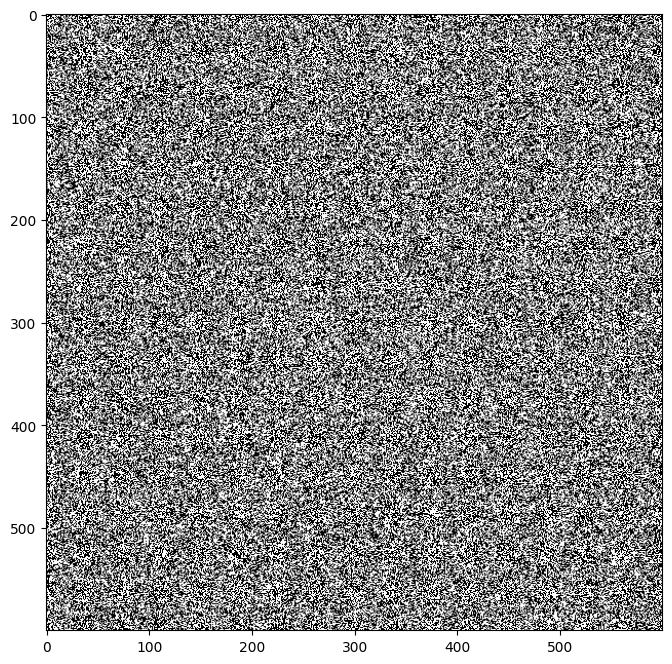

In [72]:
display_img(black_noise)

In [73]:
black_noise_img = img + black_noise

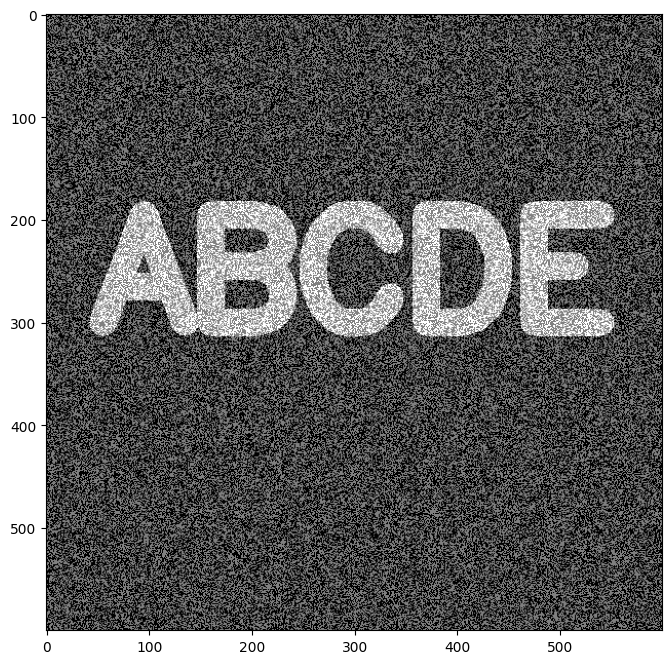

In [76]:
display_img(black_noise_img)

In [77]:
black_noise_img

array([[   0., -255.,    0., ..., -255.,    0., -255.],
       [   0.,    0., -255., ..., -255.,    0., -255.],
       [   0., -255., -255., ...,    0., -255., -255.],
       ...,
       [   0., -255., -255., ...,    0., -255.,    0.],
       [-255.,    0., -255., ..., -255.,    0., -255.],
       [   0.,    0., -255., ..., -255.,    0.,    0.]])

In [78]:
black_noise_img[black_noise_img== -255] = 0

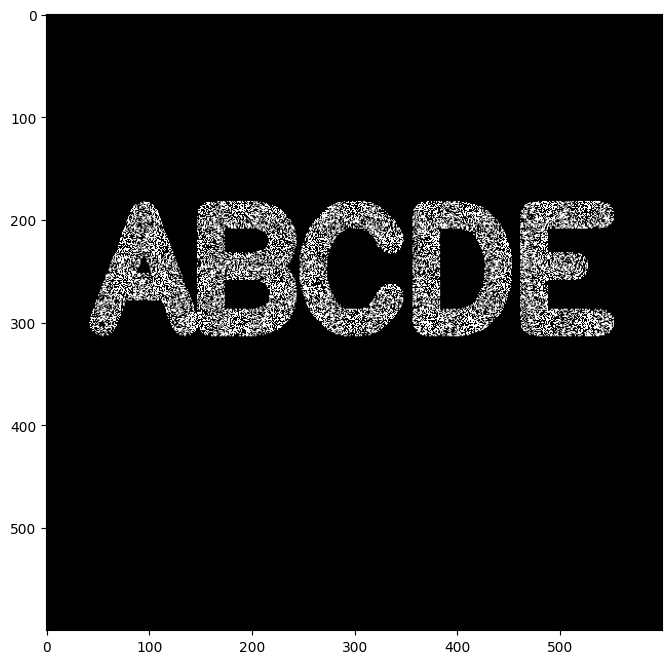

In [79]:
display_img(black_noise_img)

# CLOSING

In [80]:
closing = cv2.morphologyEx(black_noise_img, cv2.MORPH_CLOSE, kernel)

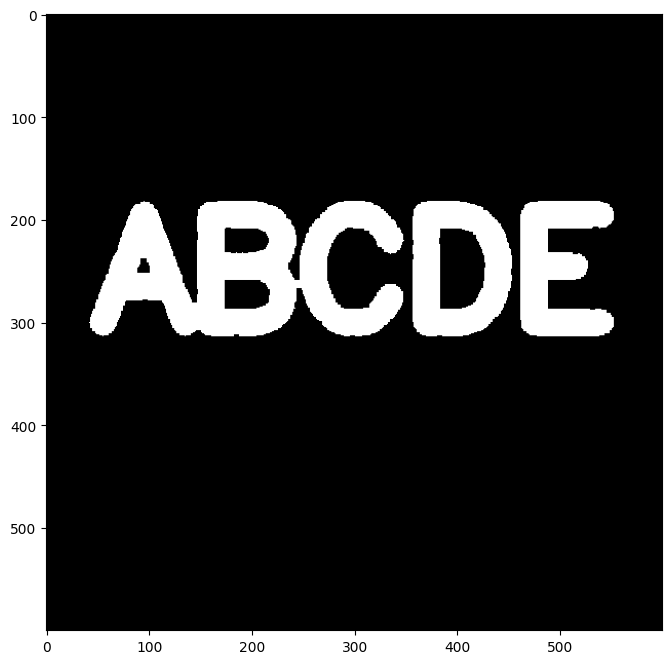

In [81]:
display_img(closing)

# Morphological Gradient

## Dilated Image - Eroded Image

In [82]:
img = load_img()

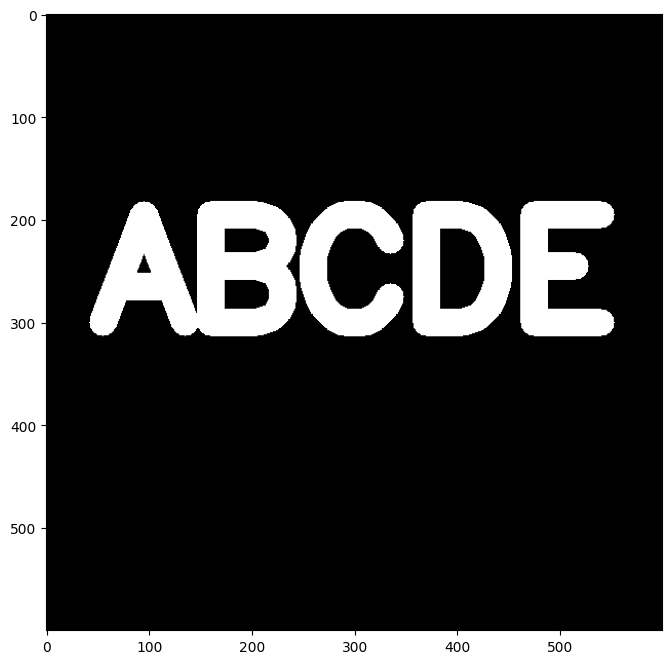

In [83]:
display_img(img)

In [84]:
gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)

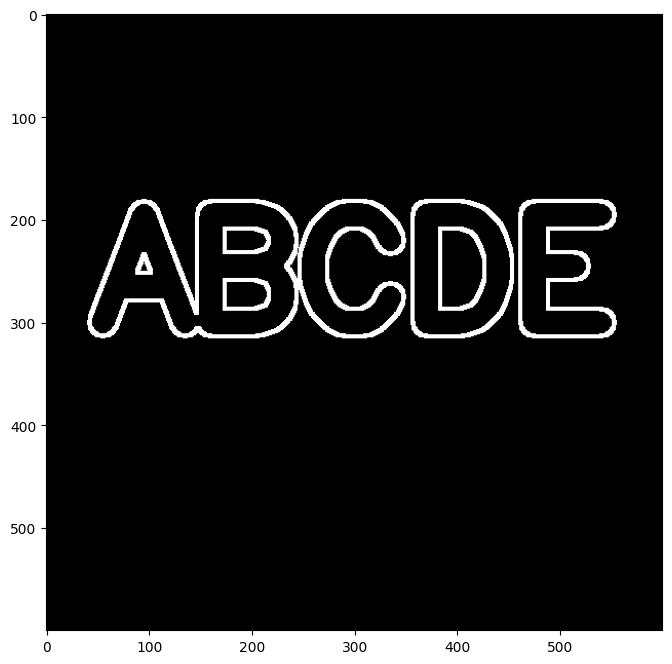

In [85]:
display_img(gradient)